In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

import pymc as pm
import arviz as az

g++ not available, if using conda: `conda install gxx`


In [2]:
# Load the dataset
df = pd.read_csv("../data/BrentOilPrices.csv")

# Display the first five rows
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [3]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


In [4]:
# Check missing values
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [5]:
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


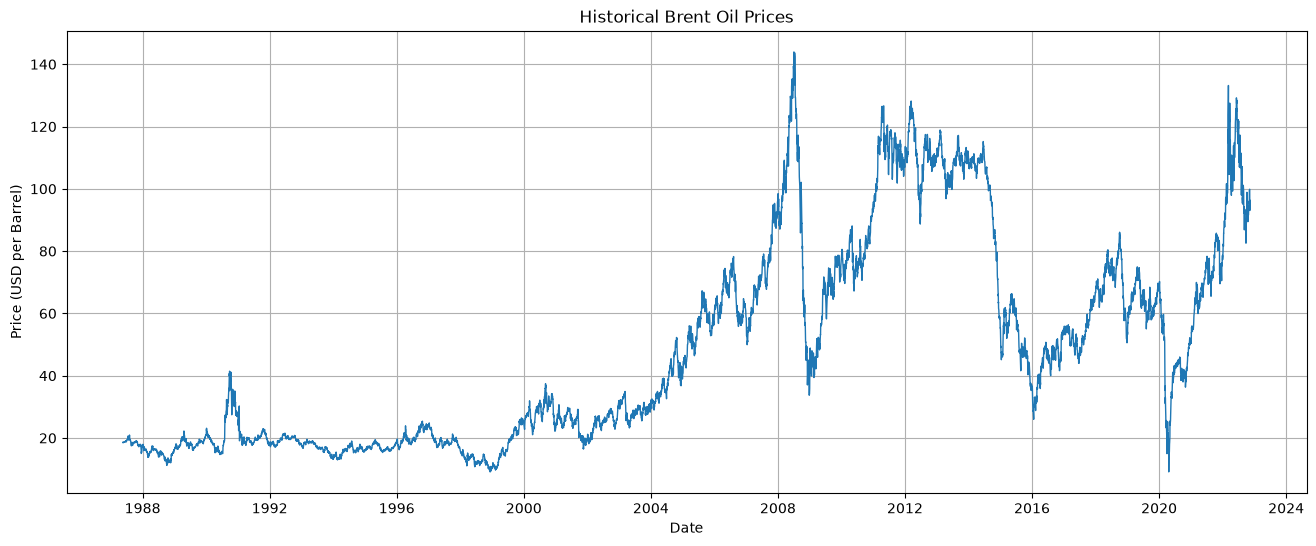

In [6]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"], linewidth=1)

plt.title("Historical Brent Oil Prices")

plt.xlabel("Date")

plt.ylabel("Price (USD per Barrel)")

plt.grid(True)

plt.show()

In [7]:
# Calculate the natural logarithm of prices
df["LogPrice"] = np.log(df["Price"])

# Display the first few rows
df.head()

,Date,Price,LogPrice
0,1987-05-20,18.63,2.924773
1,1987-05-21,18.45,2.915064
2,1987-05-22,18.55,2.920470
3,1987-05-25,18.60,2.923162
4,1987-05-26,18.63,2.924773


In [8]:
# Calculate daily log returns
df["LogReturn"] = df["LogPrice"].diff()

# Remove the first row (contains NaN)
df = df.dropna().reset_index(drop=True)

df.head()

,Date,Price,LogPrice,LogReturn
0,1987-05-21,18.45,2.915064,-0.009709
1,1987-05-22,18.55,2.920470,0.005405
2,1987-05-25,18.60,2.923162,0.002692
3,1987-05-26,18.63,2.924773,0.001612
4,1987-05-27,18.60,2.923162,-0.001612


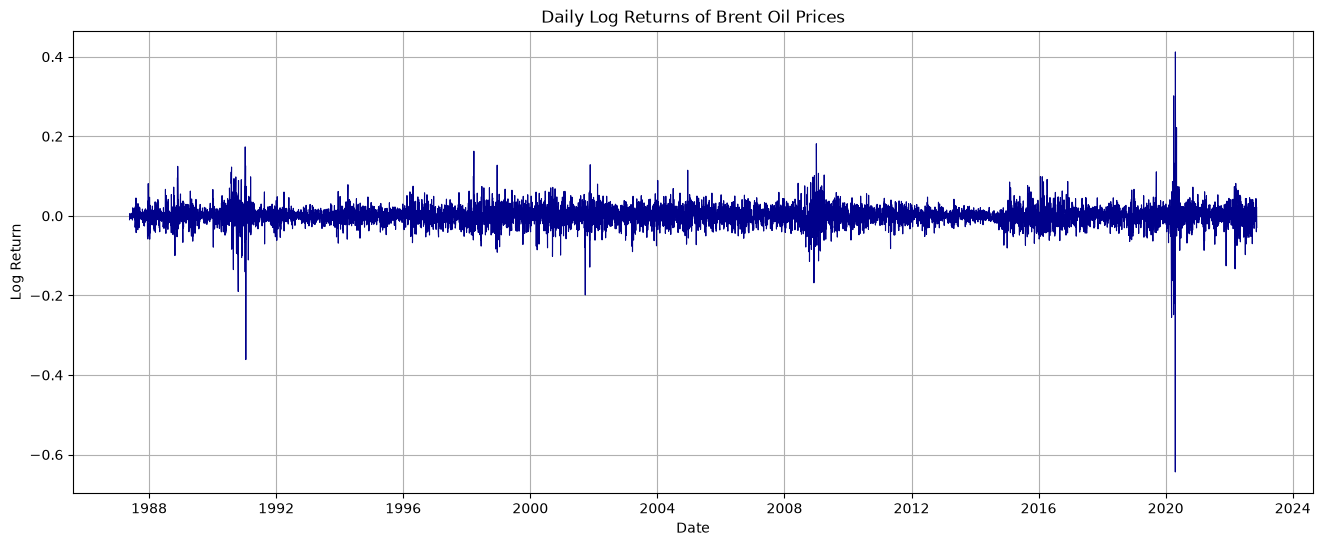

In [9]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["LogReturn"], color="darkblue", linewidth=0.8)

plt.title("Daily Log Returns of Brent Oil Prices")

plt.xlabel("Date")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [10]:
# Perform the ADF test on log returns
result = adfuller(df["LogReturn"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic : -16.427113494485894
p-value       : 2.4985801611428892e-29
Critical Values:
   1%: -3.4310783342658615
   5%: -2.861861876398633
   10%: -2.566941329781918


## Stationarity Analysis

The Augmented Dickey-Fuller (ADF) test was applied to the daily log returns of Brent oil prices.

**Results**

- ADF Statistic: -16.43
- p-value: 2.50 × 10⁻²⁹

Since the p-value is much smaller than the significance level of 0.05, the null hypothesis of a unit root is rejected. Therefore, the log return series is stationary.

This indicates that the transformed series is appropriate for Bayesian change point modeling because its statistical properties remain stable over time.

In [11]:
len(df)

9010

In [12]:
# Use the last 2000 observations for Bayesian modeling
model_df = df.tail(2000).reset_index(drop=True)

print("Number of observations:", len(model_df))

model_df.head()

Number of observations: 2000


,Date,Price,LogPrice,LogReturn
0,2015-01-09,47.64,3.863673,-0.036885
1,2015-01-12,46.90,3.848018,-0.015655
2,2015-01-13,45.13,3.809547,-0.038470
3,2015-01-14,45.82,3.824721,0.015173
4,2015-01-15,47.66,3.864092,0.039372


In [13]:
# Time index
x = np.arange(len(model_df))

# Observed log returns
y = model_df["LogReturn"].values

In [14]:
with pm.Model() as change_point_model:

    # Prior for the change point
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=len(y) - 1
    )

    # Mean before the change
    mu1 = pm.Normal(
        "mu1",
        mu=0,
        sigma=1
    )

    # Mean after the change
    mu2 = pm.Normal(
        "mu2",
        mu=0,
        sigma=1
    )

    # Standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    # Switch function
    mu = pm.math.switch(
        x < tau,
        mu1,
        mu2
    )

    # Likelihood
    observation = pm.Normal(
        "observation",
        mu=mu,
        sigma=sigma,
        observed=y
    )

In [15]:
with change_point_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.95,
        random_seed=42
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 111 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [16]:
pm.summary(trace)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,1e+03,7e+02,5,2000,15,23,1.12,160,71
mu1,-0.001,0.007,-0.0033,0.0035,277,71,1.08,0.00077,0.0022
mu2,0.0002,0.006,-0.0047,0.0042,308,139,1.04,0.00047,0.0019
sigma,0.03373,0.00053,0.033,0.035,728,931,1.00,2e-05,1.4e-05


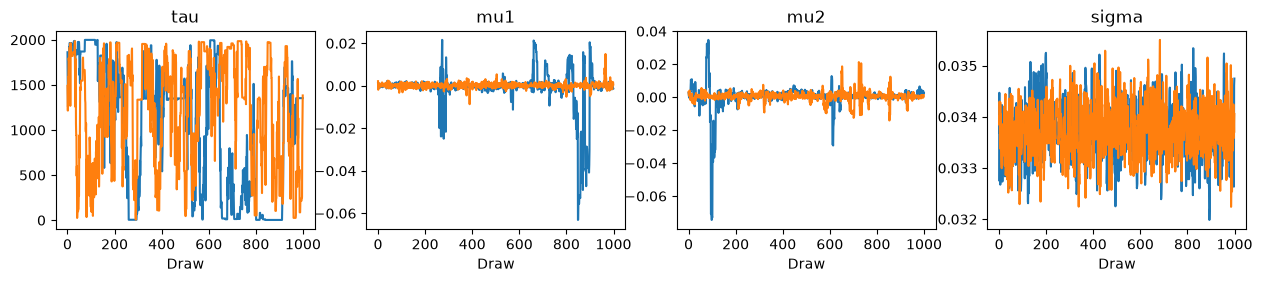

In [17]:
az.plot_trace(trace)

plt.show()

In [21]:
import arviz as az

print("Version:", az.__version__)

print("\nFunctions containing 'plot':")
print([name for name in dir(az) if "plot" in name.lower()])

Version: 1.2.0

Functions containing 'plot':
['PlotCollection', 'PlotMatrix', 'combine_plots', 'plot_autocorr', 'plot_bf', 'plot_collection', 'plot_compare', 'plot_convergence_dist', 'plot_dgof', 'plot_dgof_dist', 'plot_dist', 'plot_ecdf_pit', 'plot_energy', 'plot_ess', 'plot_ess_evolution', 'plot_forest', 'plot_khat', 'plot_lm', 'plot_loo_interval', 'plot_loo_pit', 'plot_matrix', 'plot_mcse', 'plot_pair', 'plot_pair_focus', 'plot_parallel', 'plot_ppc_censored', 'plot_ppc_dist', 'plot_ppc_dist_pit', 'plot_ppc_interval', 'plot_ppc_pava', 'plot_ppc_pava_residuals', 'plot_ppc_pit', 'plot_ppc_rootogram', 'plot_ppc_tstat', 'plot_prior_posterior', 'plot_psense_dist', 'plot_psense_quantities', 'plot_rank', 'plot_rank_dist', 'plot_ridge', 'plot_trace', 'plot_trace_dist']


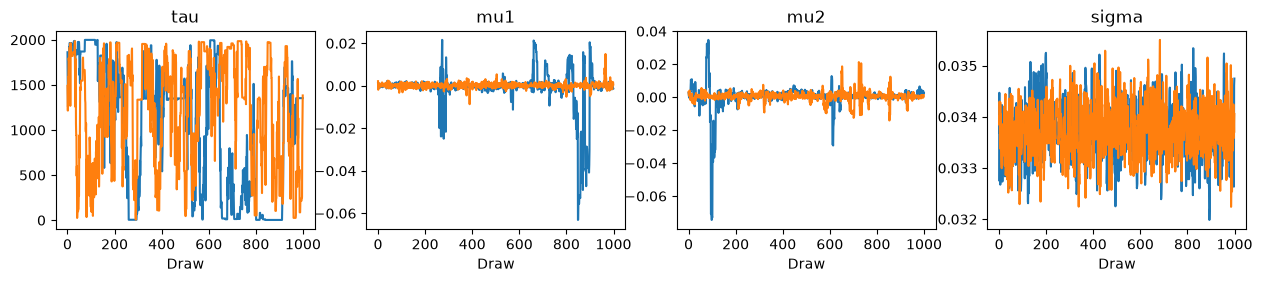

In [22]:
az.plot_trace(trace)
plt.show()

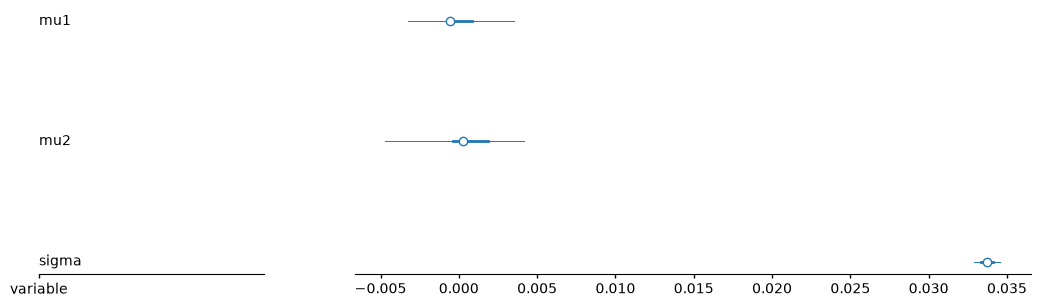

In [23]:
az.plot_forest(
    trace,
    var_names=["mu1", "mu2", "sigma"],
    combined=True
)

plt.show()

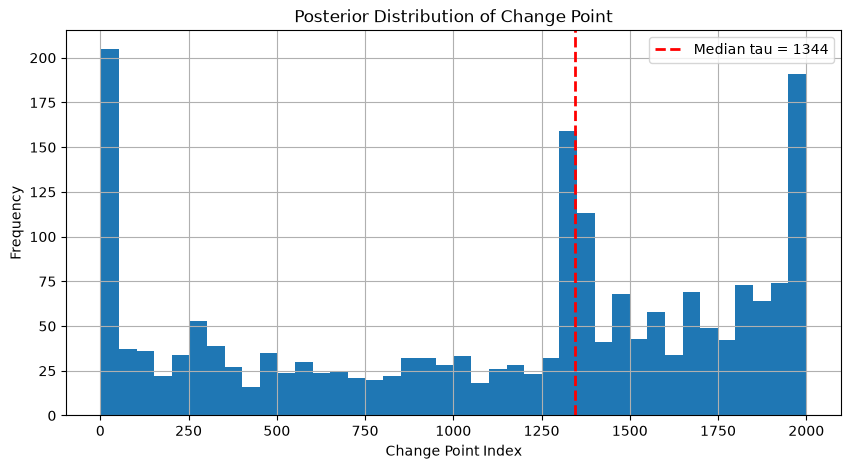

In [24]:
import matplotlib.pyplot as plt
import numpy as np

tau_samples = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.median(tau_samples))

plt.figure(figsize=(10,5))
plt.hist(tau_samples, bins=40)

plt.axvline(
    estimated_tau,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median tau = {estimated_tau}"
)

plt.title("Posterior Distribution of Change Point")
plt.xlabel("Change Point Index")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
change_date = model_df.iloc[estimated_tau]["Date"]

print("Estimated Change Point Date:", change_date)

Estimated Change Point Date: 2020-04-15 00:00:00


In [26]:
before = model_df.iloc[:estimated_tau]["Price"].mean()
after = model_df.iloc[estimated_tau:]["Price"].mean()

percent_change = ((after - before) / before) * 100

print(f"Average price before: ${before:.2f}")
print(f"Average price after : ${after:.2f}")
print(f"Percentage change   : {percent_change:.2f}%")

Average price before: $56.63
Average price after : $73.17
Percentage change   : 29.22%
